Differences in braids, will be a better approximation to the true *genetic distance* than *Jaccard*.


In [20]:
import random
import shutil 
from pathlib import Path
from cogent3 import load_aligned_seqs

# Set random seed for reproducibility
random.seed(41)

# Define your input and output directories
fasta_dir = Path("../data/mammals")  
output_dir = Path("./data")
slide_dir = Path("../../slideshows/images")  
json_outfile = output_dir / "human_chimp_pairs.json"

shutil.rmtree(output_dir, ignore_errors=True)
output_dir.mkdir(exist_ok=True)
print (f"Clean output directory: {output_dir.resolve()}")
print (f"Slide directory: {slide_dir.resolve()}")


Clean output directory: /home/richard/source/BIOL8701-RichardMorris/final_presentation/experiments/2/data
Slide directory: /home/richard/source/BIOL8701-RichardMorris/final_presentation/slideshows/images


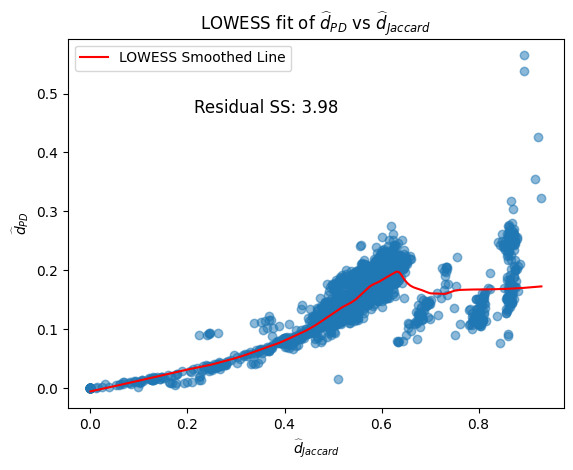

In [27]:
import cogent3
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
import numpy as np

default_kmer_size = 6
ensembl_id = 'ENSG00000158286'
alignment_file = fasta_dir / f'{ensembl_id}.fasta'
alignment = cogent3.load_aligned_seqs(alignment_file, moltype='dna')

def calculate_jaccard(kmer_size, alignment):
    jaccard = cogent3.get_app('jaccard_dist', k=kmer_size)
    jaccard_dists = jaccard(alignment.degap())
    return jaccard_dists.array.flatten()

JC69_dist = alignment.distance_matrix('pdist')
JC69_unsorted = JC69_dist.array.flatten()
Jaccard_unsorted = calculate_jaccard(default_kmer_size, alignment)
sorted_indicies = np.argsort(Jaccard_unsorted)

Jaccard_sorted = Jaccard_unsorted[sorted_indicies]
JC69_sorted = JC69_unsorted[sorted_indicies]


# Fit the LOWESS model
lowess = sm.nonparametric.lowess
lowess_unsorted = lowess(JC69_unsorted, Jaccard_unsorted, frac=0.3, return_sorted=False)  # Adjust frac as needed
lowess_sorted = lowess_unsorted[sorted_indicies]

# Calculate the sum of square differences
sum_of_square_differences = np.sum((JC69_sorted - lowess_sorted) ** 2)

plt.scatter(Jaccard_sorted, JC69_sorted, alpha=0.3)
plt.plot(Jaccard_sorted, lowess_sorted, color='red', label='LOWESS Smoothed Line')
est_jc69 = "$\\widehat d_{PD}$"
est_jac = "$\\widehat d_{Jaccard}$"
plt.xlabel(est_jac)
plt.ylabel(est_jc69)
plt.title(f"LOWESS fit of {est_jc69} vs {est_jac}") #\n {ensembl_id} homologues in {alignment.num_seqs} mammalian sequences
plt.legend()

# Add the sum of square differences as an annotation
plt.annotate(f'Residual SS: {sum_of_square_differences:.2f}', 
             xy=(0.4, 0.8), xycoords='axes fraction', fontsize=12, ha='center')


# save the plot to the msa_tools output directory and show it in the notebook
plt.savefig(slide_dir / f'PD_vs_jaccard_LOWESS_fit.png')
plt.show()

In [25]:
from pathlib import Path
from typing import Optional
import cogent3
from madb.debruijngraph import make_graph
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from itertools import combinations

def plot_madb_vs_pd(fasta_file: Path, output_dir: Optional[Path] = None, show_plot=True) -> float:
    """Plots MADB vs Proportionate Difference (PD) for a FASTA file of aligned sequences.

    Returns:
        float: residual sum of squares from LOWESS fit.
    """
    try:
        ensembl_id = fasta_file.stem
        alignment = cogent3.load_aligned_seqs(fasta_file, moltype="dna")
        unaligned = alignment.degap()
        pd_matrix = alignment.distance_matrix("pdist")

        names = unaligned.names
        seqs = dict(unaligned.named_seqs)
        pd_dists = []
        madb_dists = []

        for i, j in combinations(range(len(names)), 2):
            name1, name2 = names[i], names[j]
            seq1, seq2 = seqs[name1], seqs[name2]

            dbg = make_graph({name1: seq1, name2: seq2})
            differences, total = dbg.distance()

            if total == 0:
                continue

            madb_dists.append(differences / total)
            pd_dists.append(pd_matrix.array[i, j])

        if len(madb_dists) == 0:
            raise ValueError(f"No valid braid distances found for {ensembl_id}")

        madb_dists = np.array(madb_dists)
        pd_dists = np.array(pd_dists)

        sort_idx = np.argsort(madb_dists)
        madb_sorted = madb_dists[sort_idx]
        pd_sorted = pd_dists[sort_idx]

        lowess = sm.nonparametric.lowess
        lowess_fit = lowess(pd_dists, madb_dists, frac=0.3, return_sorted=False)
        lowess_sorted = lowess_fit[sort_idx]

        rss = np.sum((pd_sorted - lowess_sorted) ** 2)

        if output_dir:
            output_dir.mkdir(parents=True, exist_ok=True)
            output_file = output_dir / f"{ensembl_id}_madb_vs_pd_LOWESS.png"
        else:
            output_file = None

        # Plotting
        plt.figure(figsize=(8, 6))
        plt.scatter(madb_sorted, pd_sorted, alpha=0.5, label='Observed')
        plt.plot(madb_sorted, lowess_sorted, color='red', label='LOWESS')

        plt.xlabel("$\\widehat d_{MADB}$")
        plt.ylabel("$\\widehat d_{PD}$")
        plt.title(f"LOWESS fit: MADB vs PD\n{ensembl_id} across {alignment.num_seqs} mammals")
        plt.legend()
        plt.annotate(f'Residual SS = {rss:.2f}', xy=(0.5, 0.85), xycoords='axes fraction', ha='center', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()

        if output_file:
            plt.savefig(output_file)
        if show_plot:
            plt.show()
        else:
            plt.close()

        return rss

    except Exception as e:
        raise RuntimeError(f"Error in file {fasta_file.name}: {e}")



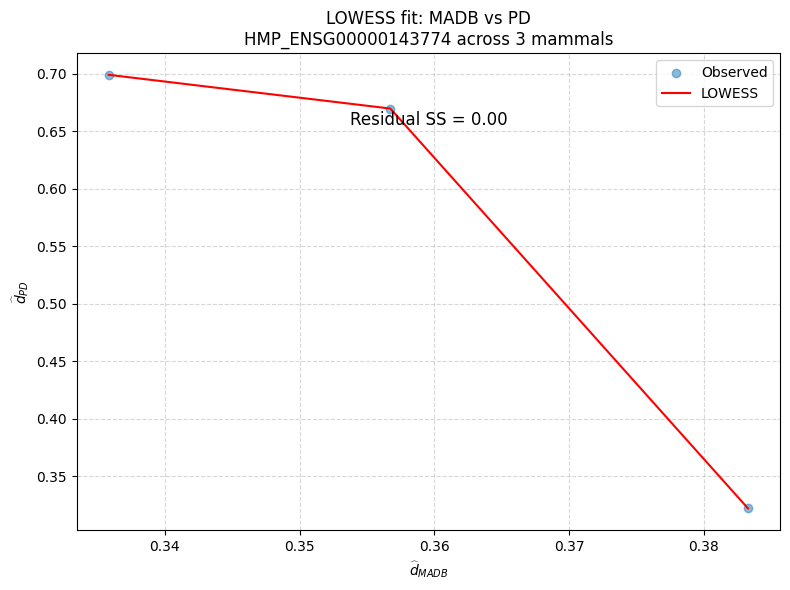

np.float64(0.0)

In [26]:
good_files = []
bad_files = []

hcp_dir = Path("../data/hcm") 
fasta_file = hcp_dir / "HMP_ENSG00000143774.fa"

plot_madb_vs_pd(fasta_file, output_dir=Path("../../slideshows/images"), show_plot=True)

# for fasta_file in hcp_dir.glob("*.fa"):
#     try:
#         print(f"Processing: {fasta_file.name}")
#         rss = plot_madb_vs_pd(fasta_file, output_dir=Path("../../slideshows/images"), show_plot=True)
#         print(f"  ✅ Success: RSS = {rss:.2f}")
#         good_files.append((fasta_file.name, rss))
#     except Exception as err:
#         print(f"  ❌ Failed: {err}")
#         bad_files.append((fasta_file.name, str(err)))
